# Riddles

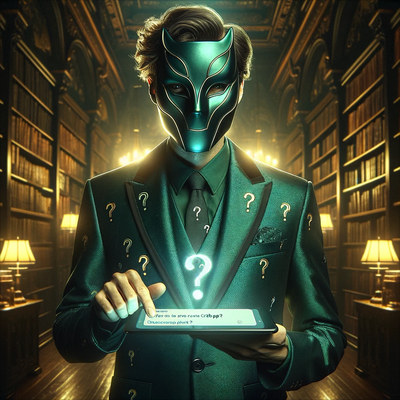

## Introduction
Riddles have fascinated people for centuries, stimulating their minds toward creative and logical thinking. From simple puzzles to profound philosophical conundrums, they serve not only as a form of entertainment but also as an art of understanding language and logical reasoning. In this task, you will solve riddles consisting of guessing a word based on its description. All riddles were generated by ChatGPT (but we won't say exactly which version or how it was prompted), hence some might be a bit weird... We estimate that humans can correctly solve slightly over 60% of them. How good will your program be?

## Task
Write a function `answer_riddle` that will solve the riddle provided as input. The solution is always a single word. Example riddles:

- **riddle:** a woman traveling by a means of transport, e.g., an airplane, train, ship <br>
  **answer:** passenger (pasażerka)
- **riddle:** an emotional feeling connecting two people, based on trust, respect, care, and devotion<br>
  **answer:** love (miłość)

Our criterion will be the `Mean Reciprocal Rank` ([Mean Reciprocal Rank](https://en.wikipedia.org/wiki/Mean_reciprocal_rank)), which works as follows: <br>
If the correct answer appears in the list returned by your function, you will receive points: exactly $\frac{1}{k}$ points, where $k$ is the position of the word on the list. In particular, if your program guesses the word exactly (placing it in the first position), you receive 1 point. The final criterion is the average number of points from all riddles.

The above criterion is implemented by us below.

## Constraints
- Your final solution will be tested in an environment **without** a GPU.
- Your function should run fast enough for the program to answer 100 riddles in a maximum of 2 minutes without using a GPU.

## Data
The data available to you in this task are:
* `zagadki_do_testow_clean.txt` - about 2000 example riddles
* `plwiktionary_definitions_clean.txt` - a file with word definitions taken from [pl.wiktionary.org](https://pl.wiktionary.org/wiki/pl). Out of all definitions from pl.wiktionary.org, we took the definitions of the 8094 most popular nouns (frequencies calculated according to the corpus https://2018.poleval.pl/index.php/tasks#task3). Note: the correct solution to each riddle is in this file!
* `superbazy_clean.txt` - base forms of Polish words, prepared based on the project https://github.com/morfologik/polimorfologik
* Base word embeddings vectors, trained with the Word2Vec model from the Gensim library on the PolEval 2018 Task3 corpus.

## Notes and Tips
- For each riddle, your function should return a list of words (at most 20), in order from the most probable answer (according to your program) to the least.
- Your solution will be tested without internet access.

## Submission Files
Only this notebook.

## Evaluation
Remember that during testing, the `FINAL_EVALUATION_MODE` flag will be set to `True`. Using the `validation_script.py` script, you will be able to ensure your solution will be correctly executed on our grading servers.

You can score between 0 and 1.5 points for this task. You will score 0 points if the `mean reciprocal rank` criterion value on the test set is below 0.02, and 1.5 points if it is above 0.3. Between these values, the score increases linearly with the criterion value.

# Starter Code

In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False
# During the evaluation of your solution, we will change this value to True
# The value of this flag M U S T be set to False in the solution you submit!

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
import nltk
from nltk.tokenize import word_tokenize as tokenize
from collections import defaultdict as dd
import math
from gensim.models import Word2Vec
import gdown
import random
import os
from tqdm import tqdm

## Data Loading

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
path_to_data = 'data/'

bases = {}
# Dictionary mapping words to their base words
all_word_definitions = dd(list)
# Dictionary containing all base words inverse document frequency
base_idf = dd(int)

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
def get_word_base(word):
    global bases
    word = word.lower()
    ret = bases.get(word)
    if ret:
        return ret
    return word

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
if not FINAL_EVALUATION_MODE:
    if not os.path.exists(f"{path_to_data}/zagadki/w2v_polish_lemmas.model") \
        or not os.path.exists(f"{path_to_data}/zagadki/w2v_polish_lemmas.model.syn1neg.npy") \
        or not os.path.exists(f"{path_to_data}/zagadki/w2v_polish_lemmas.model.wv.vectors.npy"):
            gdown.download_folder(url="https://drive.google.com/drive/folders/1P72og_ORfL3Ojf27n-g06DT0ENduPy8C?usp=sharing", output=f"./{path_to_data}")
    nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
for x in open(f'{path_to_data}/zagadki/superbazy_clean.txt'):
    word, base = x.lower().split()
    bases[word] = base

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
model = Word2Vec.load(f'{path_to_data}/zagadki/w2v_polish_lemmas.model')

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
for x in open(f'{path_to_data}/zagadki/plwiktionary_definitions_clean.txt'):
    word, definition = x.split('###')
    L = word.split()
    if len(L) == 1:
        word = L[0]

        definition = set(tokenize(definition.lower()))
        all_word_definitions[word].append(definition)
        for w in set(definition):
            base_idf[get_word_base(w)] += 1

for base in base_idf:
    base_idf[base] = -math.log(base_idf[base] / len(all_word_definitions))

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
answers = []
queries = []

with open(f'{path_to_data}/zagadki/zagadki_do_testow_clean.txt') as file:
    for line in file:
        line = line.replace(';;', '').split()
        answers.append(line[0])
        queries.append(tokenize(' '.join(line[1:])))

## Evaluation Criteria Code

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
def mean_reciprocal_rank(real_answers, computed_answers, K=20):
    positions = []

    for real_answer, computed_answer in zip(real_answers, computed_answers):
        if real_answer in computed_answer[:K]:
            pos = computed_answer.index(real_answer) + 1
            positions.append(1/pos)

    mrr = sum(positions) / len(real_answers)
    print ('Mean Reciprocal Rank =', mrr)

    return mrr

# Your Solution

This is the only section where you need to implement your code.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

skipwords = {'(', ')', ',', '.', '{', '}', '[', ']', '!', '?'}
word_vectors = model.wv

def clean_sentence(sentence):
    new_sentence = []
    for word in sorted(sentence):
        word = word.lower()
        word = get_word_base(word)
        if word not in skipwords:
            new_sentence.append(word)
    return new_sentence

for word, definition in zip(answers, queries):
    definition = set(definition)
    definition = set(clean_sentence(definition))
    all_word_definitions[word].append(definition)

def cosine(u, v):
    # Handle zero vectors to avoid division by zero
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0
    return np.dot(u, v) / (norm_u * norm_v)

weights_documents = []
for word in all_word_definitions:
    for sentence in all_word_definitions[word]:
        new_sentence = clean_sentence(sentence)
        weights_documents.append(" ".join(set(new_sentence)))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(weights_documents)
tfidf_weights = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))

def weights_sentence2vec(sentence, weights=tfidf_weights):
    vec = np.zeros(200)
    sentence = clean_sentence(sentence)
    for word in sentence:
        if word in word_vectors:
            vec += model.wv[word] * weights.get(word, 1.0)
    return vec

answer_weights = []
for word in all_word_definitions:
    for sentence in all_word_definitions[word]:
        sentence = clean_sentence(sentence)
        answer_weights.append([word, weights_sentence2vec(sentence)])

def answer_riddle(riddle, K):
    riddle = clean_sentence(riddle)
    vec = weights_sentence2vec(riddle)

    sim = []
    weights_dict = dd(float)

    # First pass: Compare query vector against definition vectors
    for ans, u in answer_weights:
        if ans in sim:
            weights_dict[ans] = max(weights_dict[ans], cosine(u, vec))
        else:
            if len(sim) < K:
                sim.append(ans)
                weights_dict[ans] = cosine(u, vec)
            else:
                sim = sorted(sim, key=lambda x: weights_dict[x])
                if weights_dict[sim[0]] < cosine(u, vec):
                    sim[0] = ans
                    weights_dict[ans] = cosine(u, vec)

    # Second pass: Fallback to directly comparing with word embeddings
    for ans in all_word_definitions:
        if ans not in word_vectors:
            continue
        if ans in sim:
            weights_dict[ans] = max(weights_dict[ans], cosine(model.wv[ans], vec))
        else:
            if len(sim) < K:
                sim.append(ans)
                weights_dict[ans] = cosine(model.wv[ans], vec)
            else:
                sim = sorted(sim, key=lambda x: weights_dict[x])
                if weights_dict[sim[0]] < cosine(model.wv[ans], vec):
                    sim[0] = ans
                    weights_dict[ans] = cosine(model.wv[ans], vec)

    sim = sorted(sim, key=lambda x: -weights_dict[x])
    return sim

# Evaluation

The following code will be used to evaluate the solution. After submitting the solution to us, the evaluate_algorithm(score_function, queries, answers, K) function will be executed. Almost identical code as below will run on the test_data directory available only to the graders.

Ensure before submitting that the entire notebook executes from start to finish without errors and without user intervention after executing the Run All command.

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
def evaluate_algorithm(score_function, queries, answers, K):
    computed_answers = []
    for query in tqdm(queries, desc="queries answered"):
        computed_answers.append(score_function(set(query), K=K))
    score = mean_reciprocal_rank(answers, computed_answers, K=K)

    return score

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
if not FINAL_EVALUATION_MODE:
    PART_OF_DATA = 100
    K = 20
    valid_queries = queries[:PART_OF_DATA]
    valid_answers = answers[:PART_OF_DATA]
    score = evaluate_algorithm(answer_riddle, valid_queries, valid_answers, K=K)
    print(f"Score: {score}")

queries answered:   0%|          | 0/100 [00:00<?, ?it/s]<ipython-input-37-63efb4afe6d7>:24: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
queries answered: 100%|██████████| 100/100 [00:46<00:00,  2.15it/s]

Mean Reciprocal Rank = 1.0
Score: 1.0
